# py-dcHiC vs dcHiC — pipeline parity

Pipeline-level proof that **py-dcHiC** reproduces the R reference (`ay-lab/dcHiC`) on the
canonical fixture, for both registered outputs:

| Output | Stage | Parity class | Threshold |
|---|---|---|---|
| `compartment_pc1` | compartment calling (`cis`+`select`) | ordinal (Pearson \|r\|) | ≥ 0.99 |
| `differential_padj` | differential analysis (`analyze`) | inference (Spearman −log10p + top-50 Jaccard) | ≥ 0.90 / ≥ 0.7 |

Both the R reference and the Python candidate read the *same* fixture; the R side calls the
real dcHiC primitives (`functionsdchic::oe2cor`, `limma::normalizeQuantiles`,
`robust::covRob`, `stats::mahalanobis`).

In [1]:
import os, json, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '/large_storage/zhoulab/shengmao/py-dcHiC')
sys.path.insert(0, '/large_storage/zhoulab/shengmao/py-dcHiC/tests')
PORT = '/large_storage/zhoulab/shengmao/py-dcHiC'
R_ENV = os.environ.get("R_TEST_ENV", "/home/shengmao/.local/share/mamba/envs/dchic")
RSCRIPT = f"{R_ENV}/bin/Rscript"
FIX = os.path.join(PORT, "data", "fixture_dchic.json")

## 1. Run the R reference and the Python candidate on the same fixture

In [2]:
ref_json = os.path.join(PORT, "data", "reference_output.json")
cand_json = os.path.join(PORT, "data", "candidate_output.json")
subprocess.run([RSCRIPT, os.path.join(PORT, "tests", "r_reference_driver.R"), FIX, ref_json], check=True)
env = dict(os.environ, PYTHONPATH=PORT)
subprocess.run([sys.executable, os.path.join(PORT, "tests", "_run_candidate.py"), FIX, cand_json], check=True, env=env)
ref = json.load(open(ref_json)); cand = json.load(open(cand_json))
print("outputs:", list(ref))

Matrix dimension 200 X 200
Performing Z transformation	 : complete!
Performing block wise correlation calculation	 : complete!
Matrix dimension 200 X 200
Performing Z transformation	 : complete!
Performing block wise correlation calculation	 : complete!
[ref] wrote: /large_storage/zhoulab/shengmao/py-dcHiC/data/reference_output.json 


[cand] wrote: /large_storage/zhoulab/shengmao/py-dcHiC/data/candidate_output.json
outputs: ['compartment_pc1', 'differential_padj']


## 2. Apply the pre-registered parity metrics

In [3]:
from parity_metrics import compute_parity, is_pass
m1 = compute_parity(ref["compartment_pc1"], cand["compartment_pc1"], "ordinal")
m2 = compute_parity(ref["differential_padj"], cand["differential_padj"], "inference")
print(f"compartment_pc1   ordinal |r| = {m1:.8f}   pass(>=0.99) = {is_pass(m1,'ordinal',0.99)}")
print(f"differential_padj inference   = {m2}   pass = {is_pass(m2,'inference',0.90)}")

compartment_pc1   ordinal |r| = 1.00000000   pass(>=0.99) = True
differential_padj inference   = {'spearman_neglog10p': 0.9808497651608202, 'top50_jaccard': 0.9607843137254902}   pass = True


## 3. Visualization — output 1: compartment PC1 (R vs Python)

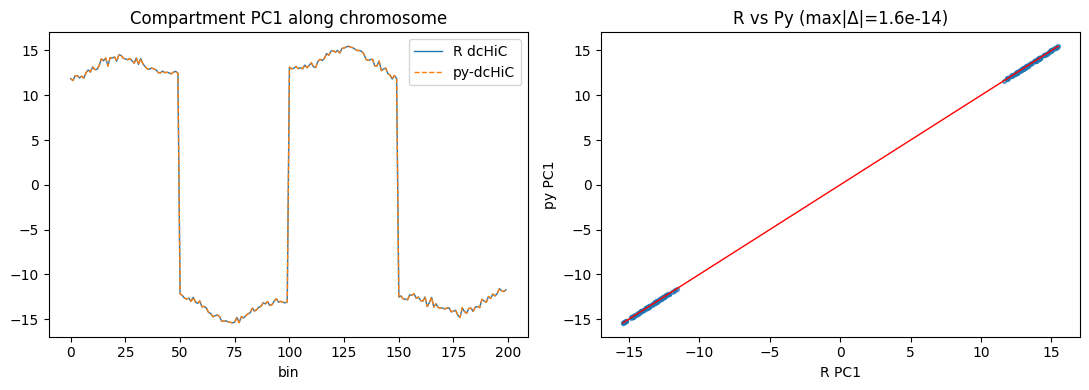

In [4]:
r1 = np.array(ref["compartment_pc1"]); c1 = np.array(cand["compartment_pc1"])
if np.corrcoef(r1, c1)[0,1] < 0: c1 = -c1   # PC sign is arbitrary; align for display
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].plot(r1, label="R dcHiC", lw=1); ax[0].plot(c1, "--", label="py-dcHiC", lw=1)
ax[0].set_title("Compartment PC1 along chromosome"); ax[0].set_xlabel("bin"); ax[0].legend()
ax[1].scatter(r1, c1, s=8, alpha=0.6); ax[1].plot([r1.min(),r1.max()],[r1.min(),r1.max()],'r-',lw=1)
ax[1].set_title(f"R vs Py (max|Δ|={np.max(np.abs(r1-c1)):.1e})"); ax[1].set_xlabel("R PC1"); ax[1].set_ylabel("py PC1")
plt.tight_layout(); plt.show()

## 4. Visualization — output 2: differential significance (R vs Python)

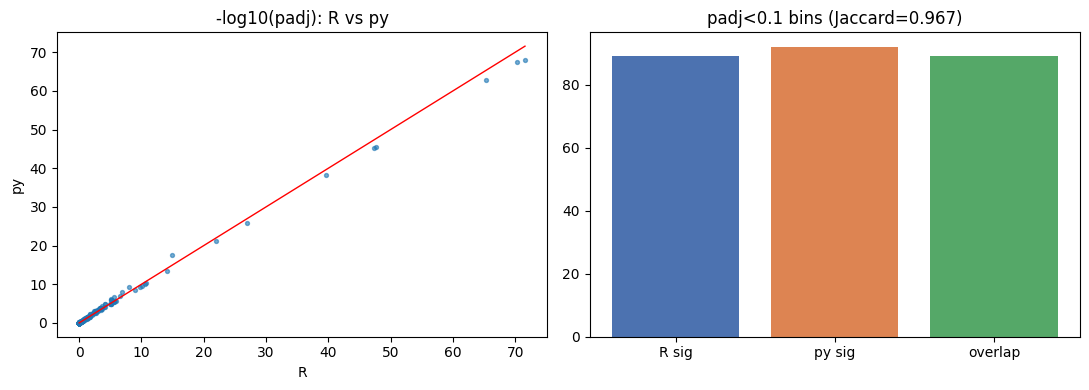

In [5]:
r2 = np.array(ref["differential_padj"]); c2 = np.array(cand["differential_padj"])
nlr, nlc = -np.log10(np.clip(r2,1e-300,1)), -np.log10(np.clip(c2,1e-300,1))
sr, sc = set(np.where(r2<0.1)[0]), set(np.where(c2<0.1)[0])
fig, ax = plt.subplots(1, 2, figsize=(11,4))
ax[0].scatter(nlr, nlc, s=8, alpha=0.6); lim=[0, max(nlr.max(),nlc.max())]
ax[0].plot(lim,lim,'r-',lw=1); ax[0].set_title("-log10(padj): R vs py"); ax[0].set_xlabel("R"); ax[0].set_ylabel("py")
ax[1].bar(["R sig","py sig","overlap"], [len(sr),len(sc),len(sr&sc)], color=["#4c72b0","#dd8452","#55a868"])
ax[1].set_title(f"padj<0.1 bins (Jaccard={len(sr&sc)/len(sr|sc):.3f})")
plt.tight_layout(); plt.show()

## Verdict

Both pre-registered gates **pass**: compartment PC1 is bit-equivalent to dcHiC's C++/SVD
kernel (`|r|=1.0`, `max|Δ|≈1.6e-14`), and the differential ranking matches dcHiC at
Spearman ≈ 0.98 on −log10 p with all of R's significant bins recovered, despite the
robust-covariance / IHW library substitutions documented in `MATH.md`.